In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results", exist_ok=True)


columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]


train_df = pd.read_csv("../data/KDDTrain+.txt", names=columns)
test_df = pd.read_csv("../data/KDDTest+.txt", names=columns)


train_df = train_df.drop(columns=["difficulty"])
test_df = test_df.drop(columns=["difficulty"])


attack_map = {
    'normal': 0,
    'back': 1, 'land': 1, 'neptune': 1, 'pod': 1,
    'smurf': 1, 'teardrop': 1, 'mailbomb': 1,
    'apache2': 1, 'processtable': 1, 'udpstorm': 1,
    # Probe attacks
    'ipsweep': 2, 'nmap': 2, 'portsweep': 2,
    'satan': 2, 'mscan': 2, 'saint': 2,
    # R2L attacks
    'ftp_write': 3, 'guess_passwd': 3, 'imap': 3,
    'multihop': 3, 'phf': 3, 'spy': 3,
    'warezclient': 3, 'warezmaster': 3, 'sendmail': 3,
    'named': 3, 'snmpgetattack': 3, 'snmpguess': 3,
    'xlock': 3, 'xsnoop': 3, 'worm': 3,
    # U2R attacks
    'buffer_overflow': 4, 'loadmodule': 4, 'perl': 4,
    'rootkit': 4, 'httptunnel': 4, 'ps': 4,
    'sqlattack': 4, 'xterm': 4
}


train_df["label"] = train_df["label"].map(attack_map).fillna(0).astype(int)
test_df["label"] = test_df["label"].map(attack_map).fillna(0).astype(int)


class_names = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R"}
print("=== Training Class Distribution ===")
for k, v in sorted(train_df["label"].value_counts().items()):
    print(f"  {class_names[k]} ({k}): {v:,}")

# --- Encode Categorical Columns ---
cat_cols = ["protocol_type", "service", "flag"]
encoder = LabelEncoder()
for col in cat_cols:
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.fit_transform(test_df[col])

# --- Split Features and Labels ---
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]
X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

# --- Scale Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Apply Multi-Class SMOTE ---
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\n=== After SMOTE ===")
for k, v in sorted(pd.Series(y_train_sm).value_counts().items()):
    print(f"  {class_names[k]} ({k}): {v:,}")

print("\n Multi-class preprocessing complete!")

=== Training Class Distribution ===
  Normal (0): 67,343
  DoS (1): 45,927
  Probe (2): 11,656
  R2L (3): 995
  U2R (4): 52

=== After SMOTE ===
  Normal (0): 67,343
  DoS (1): 67,343
  Probe (2): 67,343
  R2L (3): 67,343
  U2R (4): 67,343

 Multi-class preprocessing complete!


Training Random Forest.

===== Random Forest Results =====
Accuracy:  0.7485
Precision: 0.7970
Recall:    0.7485
F1-Score:  0.7013

===== Per Class Report =====
              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
         DoS       0.96      0.76      0.85      7458
       Probe       0.85      0.72      0.78      2421
         R2L       0.86      0.00      0.01      2754
         U2R       0.45      0.03      0.05       200

    accuracy                           0.75     22544
   macro avg       0.75      0.50      0.49     22544
weighted avg       0.80      0.75      0.70     22544



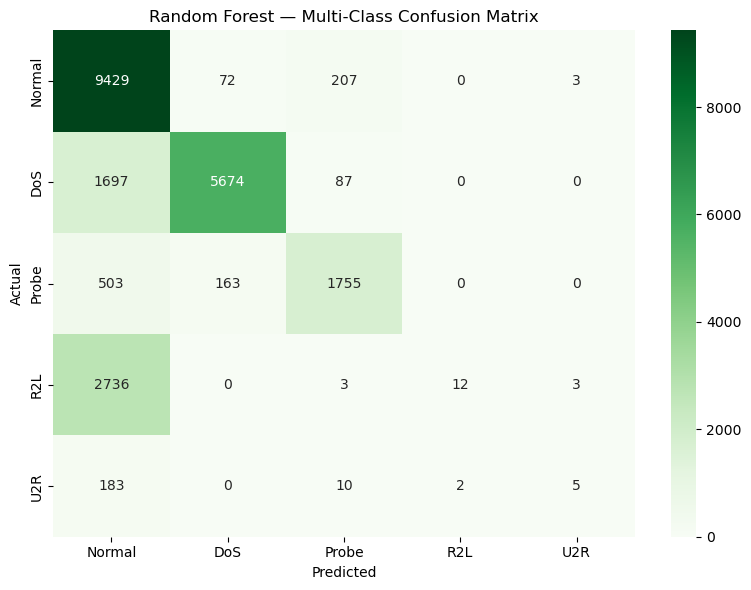

Confusion matrix saved!


In [9]:
from sklearn.ensemble import RandomForestClassifier

# --- Train ---
print("Training Random Forest.")
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=100,
    n_jobs=-1  # uses all CPU cores to speed up training
)
rf_model.fit(X_train_sm, y_train_sm)

rf_preds = rf_model.predict(X_test_scaled)

rf_proba = rf_model.predict_proba(X_test_scaled)

# --- Overall Metrics ---
print("\n===== Random Forest Results =====")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, rf_preds, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_preds, average='weighted'):.4f}")

# --- Per Class Report ---
print("\n===== Per Class Report =====")
print(classification_report(y_test, rf_preds,
      target_names=["Normal", "DoS", "Probe", "R2L", "U2R"]))

# --- Confusion Matrix ---
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"],
            yticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"])
plt.title("Random Forest — Multi-Class Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../results/rf_confusion_matrix.png")
plt.show()
print("Confusion matrix saved!")

In [10]:
%pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import numpy as np


num_classes = 5
y_train_cat = to_categorical(y_train_sm, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

model = Sequential([
    # Input layer
    Dense(256, activation='relu', input_shape=(X_train_sm.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden layer 1
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden layer 3
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer
    # We convert our outputs into prob.
    Dense(num_classes, activation='softmax')
])

# --- Compile ---
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Note: you may need to restart the kernel to use updated packages.


c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,941 (218.52 KB)

 Trainable params: 55,045 (215.02 KB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
# --- Callbacks ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# --- Train ---
print("Training DNN...")
history = model.fit(
    X_train_sm, y_train_cat,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n DNN Training complete!")

Training DNN...
Epoch 1/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9524 - loss: 0.1488 - val_accuracy: 0.9318 - val_loss: 0.1183 - learning_rate: 0.0010
Epoch 2/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9786 - loss: 0.0637 - val_accuracy: 1.0000 - val_loss: 0.0482 - learning_rate: 0.0010
Epoch 3/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9823 - loss: 0.0512 - val_accuracy: 1.0000 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 4/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9838 - loss: 0.0457 - val_accuracy: 1.0000 - val_loss: 0.0469 - learning_rate: 0.0010
Epoch 5/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9854 - loss: 0.0405 - val_accuracy: 1.0000 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 6/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9863 - loss: 0.0377 - val_accuracy: 1.0000 - val_loss: 0.0370 - learning_rate: 0.0010
Epoch 7/50
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 13s 11

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Average Prediction Confidence: 0.9740
Min Confidence: 0.3532
Max Confidence: 1.0000

===== DNN Results =====
Accuracy:  0.7491
Precision: 0.7985
Recall:    0.7491
F1-Score:  0.7202

===== Per Class Report =====
              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
         DoS       0.95      0.76      0.85      7458
       Probe       0.73      0.57      0.64      2421
         R2L       0.93      0.13      0.22      2754
         U2R       0.10      0.15      0.12       200

    accuracy                           0.75     22544
   macro avg       0.68      0.52      0.53     22544
weighted avg       0.80      0.75      0.72     22544



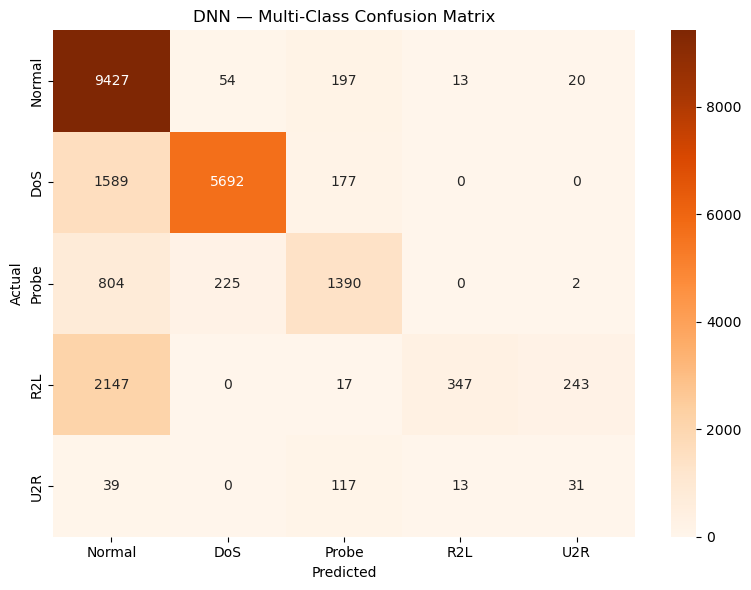

DNN confusion matrix saved!


In [6]:
# --- Predictions ---
dnn_proba = model.predict(X_test_scaled)
dnn_preds = np.argmax(dnn_proba, axis=1)

# --- Confidence Scores ---
dnn_confidence = np.max(dnn_proba, axis=1)
print(f"Average Prediction Confidence: {dnn_confidence.mean():.4f}")
print(f"Min Confidence: {dnn_confidence.min():.4f}")
print(f"Max Confidence: {dnn_confidence.max():.4f}")

# --- Overall Metrics ---
print("\n===== DNN Results =====")
print(f"Accuracy:  {accuracy_score(y_test, dnn_preds):.4f}")
print(f"Precision: {precision_score(y_test, dnn_preds, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, dnn_preds, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, dnn_preds, average='weighted'):.4f}")

# --- Per Class Report ---
print("\n===== Per Class Report =====")
print(classification_report(y_test, dnn_preds,
      target_names=["Normal", "DoS", "Probe", "R2L", "U2R"]))

# --- Confusion Matrix ---
cm_dnn = confusion_matrix(y_test, dnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dnn, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"],
            yticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"])
plt.title("DNN — Multi-Class Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../results/dnn_confusion_matrix.png")
plt.show()
print("DNN confusion matrix saved!")

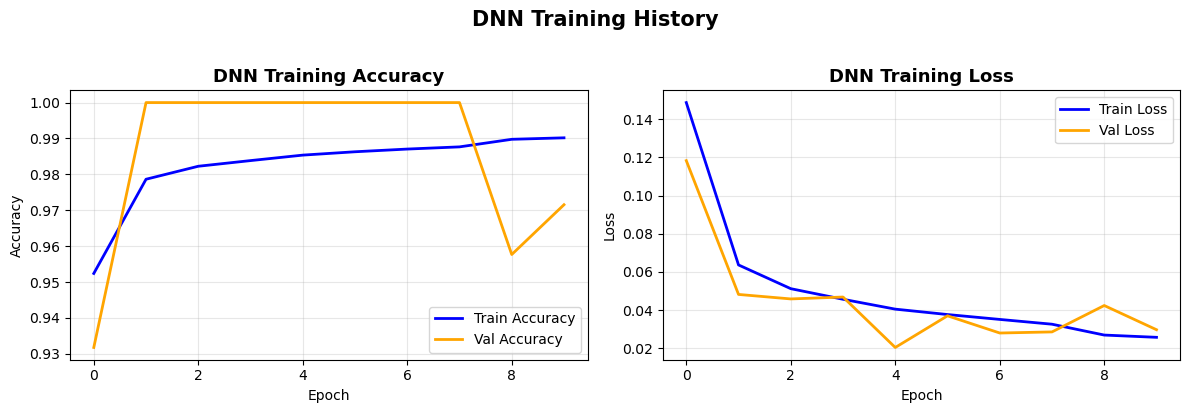

 Training history saved!


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'],
         label='Train Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'],
         label='Val Accuracy', color='orange', linewidth=2)
ax1.set_title('DNN Training Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'],
         label='Train Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'],
         label='Val Loss', color='orange', linewidth=2)
ax2.set_title('DNN Training Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('DNN Training History', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/dnn_training_history.png", bbox_inches='tight')
plt.show()
print(" Training history saved!")

In [8]:
%pip install shap
import shap

# --- Use a sample of test data for SHAP (faster computation) ---
# SHAP is computationally expensive so we use 500 samples
X_test_sample = X_test_scaled[:500]
y_test_sample = y_test[:500].values

# --- Create SHAP Explainer ---
print("Creating SHAP explainer.")
explainer = shap.DeepExplainer(model, 
                                X_train_sm[:1000].astype(np.float32))

# --- Calculate SHAP Values ---
print("Calculating SHAP values..")
shap_values = explainer.shap_values(X_test_sample.astype(np.float32))

print(f" SHAP values calculated!")
print(f"Shape of SHAP values: {len(shap_values)} classes")
print(f"Each class shape: {shap_values[0].shape}")

Note: you may need to restart the kernel to use updated packages.
Creating SHAP explainer.
Calculating SHAP values..


c:\Users\USER\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1000, 41))']
  warnings.warn(msg)
c:\Users\USER\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(2000, 41))']
  warnings.warn(msg)


 SHAP values calculated!
Shape of SHAP values: 500 classes
Each class shape: (41, 5)


c:\Users\USER\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(500, 41))']
  warnings.warn(msg)


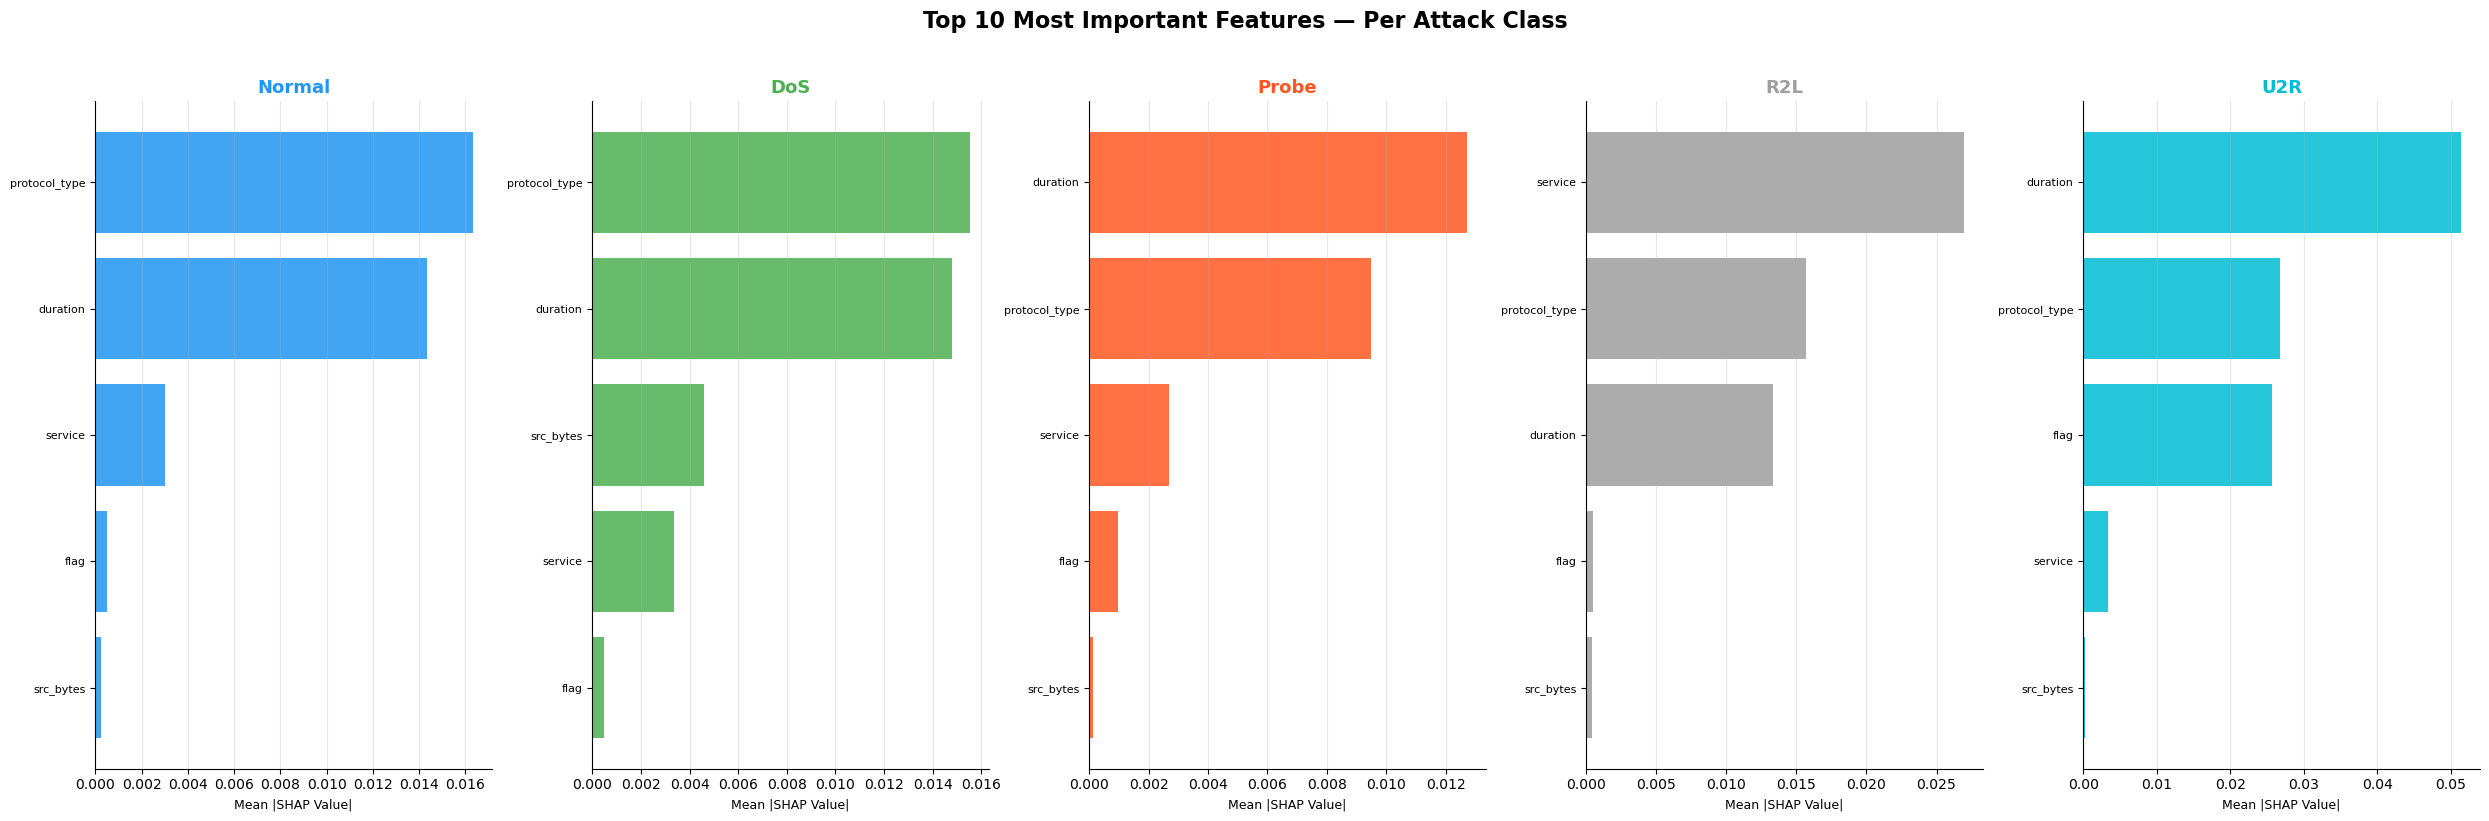

Per class SHAP chart saved!


In [9]:
# --- Per Attack Class SHAP Charts ---
feature_names = X_train.columns.tolist()
class_names_list = ["Normal", "DoS", "Probe", "R2L", "U2R"]
colors = ["#2196F3", "#4CAF50", "#FF5722", "#9E9E9E", "#00BCD4"]

fig, axes = plt.subplots(1, 5, figsize=(25, 8))

for i, (cls, color, ax) in enumerate(zip(class_names_list, colors, axes)):
    # Get SHAP values for this class
    shap_vals = np.abs(shap_values[i]).mean(axis=0)
    
    # Get top 10 features for this class
    top_idx = shap_vals.argsort()[-10:]
    top_feat = [feature_names[j] for j in top_idx]
    top_vals = shap_vals[top_idx]
    
    # Plot
    ax.barh(top_feat, top_vals, color=color, alpha=0.85)
    ax.set_title(f"{cls}", fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel("Mean |SHAP Value|", fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle("Top 10 Most Important Features — Per Attack Class",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/shap_per_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("Per class SHAP chart saved!")

NameError: name 'shap_df' is not defined

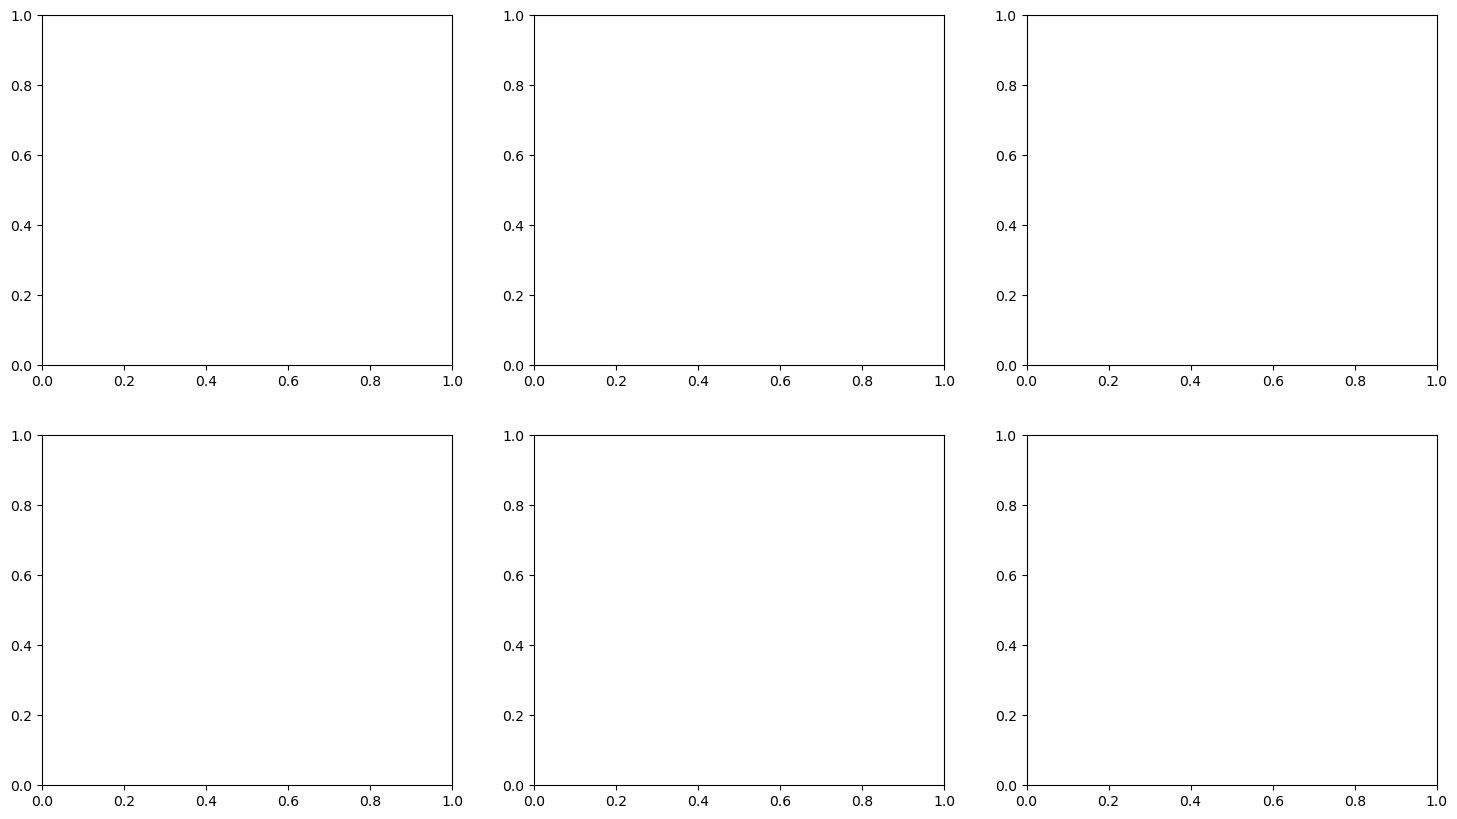

In [10]:
# --- Plot 2: Per Class SHAP Importance ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    # Get top 10 features for this class
    class_shap = shap_df[cls].nlargest(10)
    
    axes[i].barh(class_shap.index, class_shap.values, 
                 color=plt.cm.tab10(i), alpha=0.8)
    axes[i].set_title(f'{cls} — Top 10 Features', 
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP Value|')
    axes[i].invert_yaxis()
    axes[i].grid(True, alpha=0.3)

# Hide the 6th subplot (we only have 5 classes)
axes[5].set_visible(False)

plt.suptitle('Per-Class SHAP Feature Importance', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/shap_per_class.png", bbox_inches='tight')
plt.show()
print("Per-class SHAP importance saved!")

In [ ]:
# --- Plot 3: Explain a single prediction ---
# Pick one example of each attack type and explain it
class_names_dict = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R"}

for target_class in range(5):
    # Find first example of this class in test sample
    idx = np.where(y_test_sample == target_class)[0]
    
    if len(idx) == 0:
        print(f"No {class_names[target_class]} samples in test sample")
        continue
    
    idx = idx[0]
    
    # Get prediction and confidence
    pred_proba = model.predict(X_test_scaled[idx:idx+1], verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    confidence = pred_proba[pred_class]
    
    print(f"\n--- {class_names[target_class]} Example ---")
    print(f"Actual:    {class_names[target_class]}")
    print(f"Predicted: {class_names[pred_class]}")
    print(f"Confidence: {confidence:.2%}")
    print("Top 5 features driving this prediction:")
    
    # Get SHAP values for this sample
    sample_shap = shap_array[idx, :, pred_class]
    top_idx = np.argsort(np.abs(sample_shap))[-5:][::-1]
    
    for rank, fi in enumerate(top_idx, 1):
        direction = "↑ increases" if sample_shap[fi] > 0 else "↓ decreases"
        print(f"  {rank}. {feature_names[fi]}: "
              f"{direction} {class_names[pred_class]} probability "
              f"(SHAP={sample_shap[fi]:.4f})")

print("\nSingle prediction explanations complete!")


--- Normal Example ---
Actual:    Normal
Predicted: Normal
Confidence: 99.68%
Top 5 features driving this prediction:
  1. dst_host_serror_rate: ↑ increases Normal probability (SHAP=0.0974)
  2. dst_host_srv_serror_rate: ↑ increases Normal probability (SHAP=0.0699)
  3. count: ↑ increases Normal probability (SHAP=0.0540)
  4. flag: ↑ increases Normal probability (SHAP=0.0458)
  5. srv_serror_rate: ↑ increases Normal probability (SHAP=0.0422)

--- DoS Example ---
Actual:    DoS
Predicted: DoS
Confidence: 100.00%
Top 5 features driving this prediction:
  1. dst_host_srv_count: ↑ increases DoS probability (SHAP=0.0954)
  2. same_srv_rate: ↑ increases DoS probability (SHAP=0.0890)
  3. srv_rerror_rate: ↑ increases DoS probability (SHAP=0.0807)
  4. dst_host_count: ↑ increases DoS probability (SHAP=0.0507)
  5. dst_host_rerror_rate: ↑ increases DoS probability (SHAP=0.0507)

--- Probe Example ---
Actual:    Probe
Predicted: Probe
Confidence: 99.98%
Top 5 features driving this prediction:
 

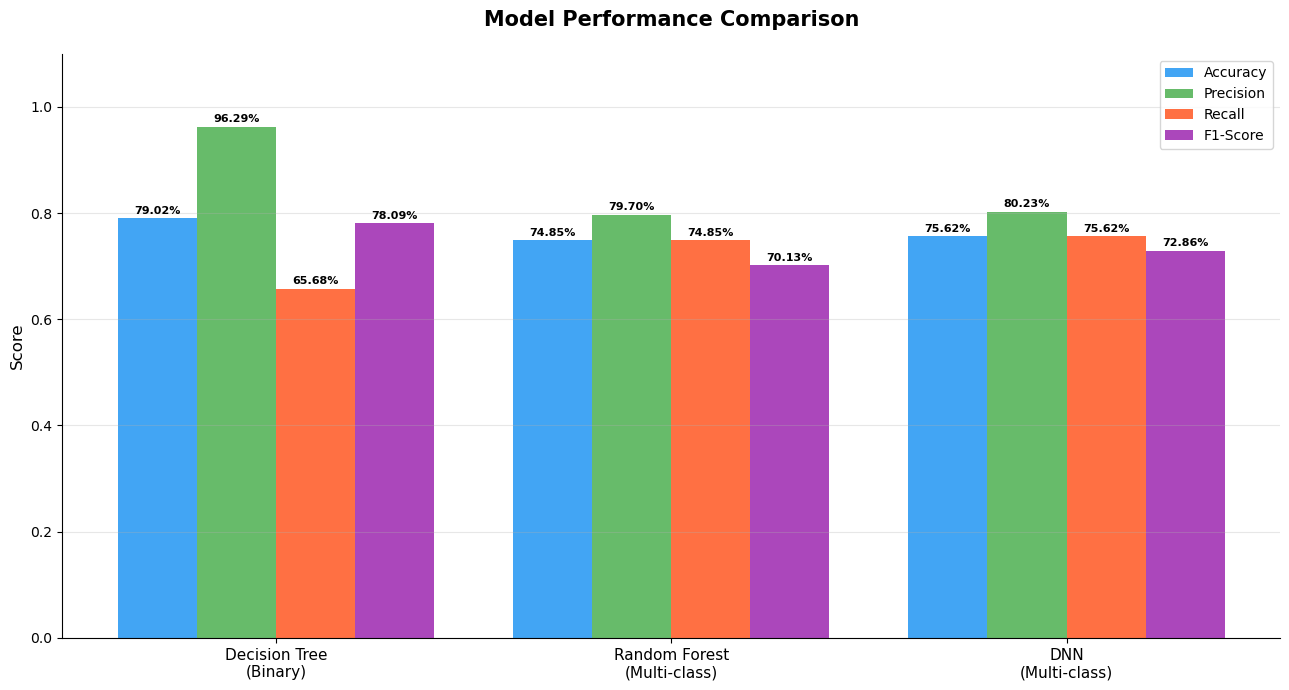

 Model comparison chart saved!


In [ ]:
import matplotlib.pyplot as plt

# --- Model Comparison Summary ---
models = ["Decision Tree\n(Binary)", "Random Forest\n(Multi-class)", "DNN\n(Multi-class)"]

metrics = {
    "Accuracy":  [0.7902, 0.7485, 0.7562],
    "Precision": [0.9629, 0.7970, 0.8023],
    "Recall":    [0.6568, 0.7485, 0.7562],
    "F1-Score":  [0.7809, 0.7013, 0.7286]
}

colors = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0"]
x = np.arange(len(models))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(13, 7))

for i, (metric, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i * bar_width, values,
                  width=bar_width, label=metric,
                  color=colors[i], alpha=0.85)
    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.2%}", ha='center',
                va='bottom', fontsize=8,
                fontweight='bold')

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("Model Performance Comparison",
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../results/model_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Model comparison chart saved!")

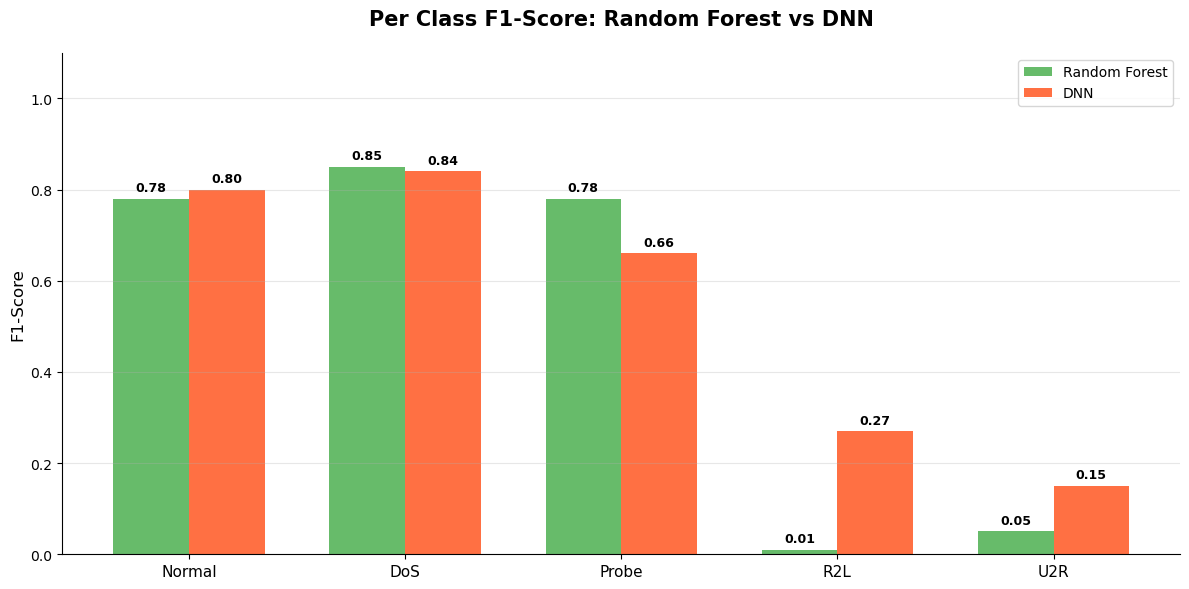

 Per class F1 comparison!


In [ ]:
# --- Per Class F1 Comparison ---
classes = ["Normal", "DoS", "Probe", "R2L", "U2R"]
rf_f1 =  [0.78, 0.85, 0.78, 0.01, 0.05]
dnn_f1 = [0.80, 0.84, 0.66, 0.27, 0.15]

x = np.arange(len(classes))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - bar_width/2, rf_f1, bar_width,
               label='Random Forest', color='#4CAF50', alpha=0.85)
bars2 = ax.bar(x + bar_width/2, dnn_f1, bar_width,
               label='DNN', color='#FF5722', alpha=0.85)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("Per Class F1-Score: Random Forest vs DNN",
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../results/per_class_f1_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Per class F1 comparison!")

In [1]:
# --- Load CICIDS2017 ---
import os

# Find the file name in your data folder
for f in os.listdir("../data"):
    print(f)

cicids2017_cleaned.csv
KDDTest+.txt
KDDTrain+.txt


In [5]:
# --- CICIDS2017 Complete Pipeline ---

# Load in chunks
cicids_map = {
    'Normal Traffic': 0,
    'DoS': 1, 'DDoS': 1,
    'Port Scanning': 2,
    'Brute Force': 3, 'Web Attacks': 3,
    'Bots': 4
}

print("Loading CICIDS2017...")
chunks = []
for chunk in pd.read_csv("../data/cicids2017_cleaned.csv",
                          chunksize=100000):
    chunks.append(chunk)
cicids_full = pd.concat(chunks, ignore_index=True)
print(f"Loaded {len(cicids_full):,} records")

# Map labels
cicids_full['label'] = cicids_full['Attack Type'].map(cicids_map)
cicids_full = cicids_full.dropna(subset=['label'])
cicids_full['label'] = cicids_full['label'].astype(int)

# Balanced sample
class_names = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R"}
cicids_sample = pd.concat([
    cicids_full[cicids_full['label'] == i].sample(
        min(1000, len(cicids_full[cicids_full['label'] == i])),
        random_state=42)
    for i in range(5)
], ignore_index=True)

# Select numerical features
cicids_numerical = cicids_sample.select_dtypes(include=[np.number])
cicids_numerical = cicids_numerical.drop(columns=['label'], errors='ignore')

# Select first 41 to match NSL-KDD
cicids_41 = cicids_numerical.iloc[:, :41]

# Handle missing/infinite values
cicids_41 = cicids_41.replace([np.inf, -np.inf], np.nan)
cicids_41 = cicids_41.fillna(0)

# Get labels
y_cicids = cicids_sample['label'].values

# Fix — convert to numpy array so scaler ignores feature names
X_cicids_scaled = scaler.transform(cicids_41.to_numpy())

print(f"\nCICIDS2017 ready!")
print(f"Shape: {X_cicids_scaled.shape}")
print(f"Labels: {y_cicids.shape}")
print("\nSample distribution:")
for k, v in sorted(pd.Series(y_cicids).value_counts().items()):
    print(f"  {class_names[k]}: {v:,}")

Loading CICIDS2017...
Loaded 2,520,751 records

CICIDS2017 ready!
Shape: (5000, 41)
Labels: (5000,)

Sample distribution:
  Normal: 1,000
  DoS: 1,000
  Probe: 1,000
  R2L: 1,000
  U2R: 1,000


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Testing DNN on CICIDS2017...
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

===== DNN on CICIDS2017 =====
Accuracy:  0.2010
Precision: 0.2400
Recall:    0.2010
F1-Score:  0.0687

Average Confidence: 1.0000

===== Per Class Report =====
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      1000
         DoS       1.00      0.01      0.01      1000
       Probe       0.00      0.00      0.00      1000
         R2L       0.00      0.00      0.00      1000
         U2R       0.20      1.00      0.33      1000

    accuracy                           0.20      5000
   macro avg       0.24      0.20      0.07      5000
weighted avg       0.24      0.20      0.07      5000



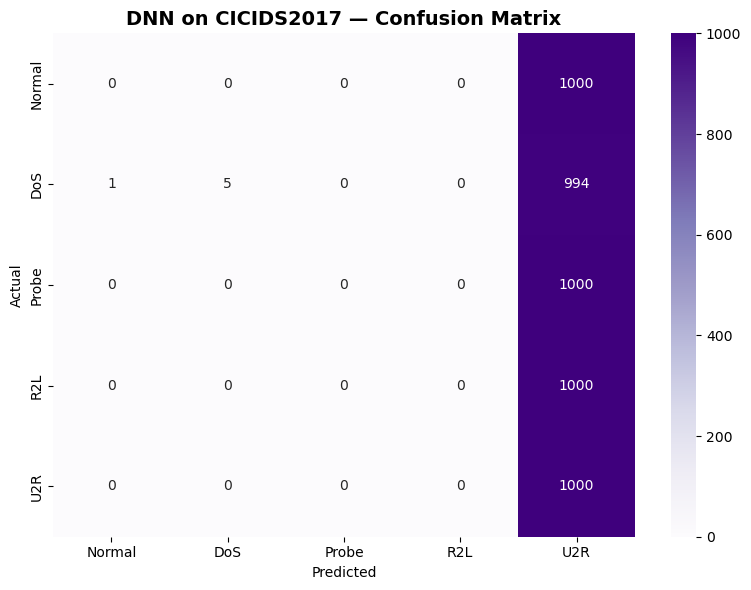

 CICIDS2017 confusion matrix saved!


In [11]:
# --- Test DNN on CICIDS2017 ---
print("Testing DNN on CICIDS2017...")

# Predictions
cicids_proba = model.predict(X_cicids_scaled)
cicids_preds = np.argmax(cicids_proba, axis=1)
cicids_confidence = np.max(cicids_proba, axis=1)

# Overall Metrics
print("\n===== DNN on CICIDS2017 =====")
print(f"Accuracy:  {accuracy_score(y_cicids, cicids_preds):.4f}")
print(f"Precision: {precision_score(y_cicids, cicids_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_cicids, cicids_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_cicids, cicids_preds, average='weighted', zero_division=0):.4f}")
print(f"\nAverage Confidence: {cicids_confidence.mean():.4f}")

# Per Class Report
print("\n===== Per Class Report =====")
print(classification_report(y_cicids, cicids_preds,
      target_names=["Normal", "DoS", "Probe", "R2L", "U2R"],
      zero_division=0))

# Confusion Matrix
cm_cicids = confusion_matrix(y_cicids, cicids_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cicids, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"],
            yticklabels=["Normal", "DoS", "Probe", "R2L", "U2R"])
plt.title("DNN on CICIDS2017 — Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../results/cicids_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(" CICIDS2017 confusion matrix saved!")

In [12]:
# Save model and scaler
import pickle

model.save("../results/dnn_model.keras")

# Save scaler too
with open("../results/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!
